In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
print(pd.__version__, yf.__version__)

3.0.6 1.7.0


In [15]:
TICKERS = ["SPY", "EFA", "TLT", "GLD"]
START = "2005-06-01"
END = "2026-09-22"

In [16]:
raw = yf.download(TICKERS, start= START, end= END, auto_adjust=True, progress=False)
raw.head()

Price           Close                                        High             \
Ticker            EFA        GLD        SPY        TLT        EFA        GLD   
Date                                                                           
2005-06-01  27.925816  41.529999  81.426720  48.049137  28.008220  41.650002   
2005-06-02  28.164074  42.099998  81.602425  48.164463  28.169449  42.279999   
2005-06-03  27.900747  42.169998  81.190216  47.768288  28.113920  42.389999   
2005-06-06  28.085255  42.480000  81.115883  48.019051  28.104960  42.650002   
2005-06-07  28.228565  42.380001  81.176704  48.400162  28.341422  42.480000   

Price                                   Low                                   \
Ticker            SPY        TLT        EFA        GLD        SPY        TLT   
Date                                                                           
2005-06-01  81.710529  48.064182  27.777132  41.400002  80.717190  47.738207   
2005-06-02  81.656480  48.239689  27.965231  41.910000  81.156433  48.008998   
2005-06-03  81.690263  48.645920  27.852380  42.169998  80.906406  47.743211   
2005-06-06  81.223999  48.084245  28.001060  42.450001  80.784772  47.818448   
2005-06-07  81.933536  48.435267  28.183779  42.310001  81.095619  48.169470   

Price            Open                                    Volume           \
Ticker            EFA        GLD        SPY        TLT      EFA      GLD   
Date                                                                       
2005-06-01  27.777132  41.410000  80.764492  47.743219  2512500  1787900   
2005-06-02  27.992102  41.919998  81.244283  48.008998  1892400  5752600   
2005-06-03  28.061971  42.330002  81.460513  48.595771  1814700  3350700   
2005-06-06  28.056595  42.560001  81.055064  47.893674  1891500  2470800   
2005-06-07  28.199901  42.480000  81.352398  48.380101  3360600   611000   

Price                          
Ticker           SPY      TLT  
Date                           
2005-06-01  69611000  3823200  
2005-06-02  39704500  1703400  
2005-06-03  60999400  5558100  
2005-06-06  36046400  1088700  
2005-06-07  66501300  1503100

In [17]:
prices = raw["Close"]
prices = prices[TICKERS]
prices.head()

Ticker,SPY,EFA,TLT,GLD
Date,,,,
2005-06-01,81.426720,27.925816,48.049137,41.529999
2005-06-02,81.602425,28.164074,48.164463,42.099998
2005-06-03,81.190216,27.900747,47.768288,42.169998
2005-06-06,81.115883,28.085255,48.019051,42.480000
2005-06-07,81.176704,28.228565,48.400162,42.380001


In [18]:
print("Dimensions :", prices.shape)
print("Première date :", prices.index.min())
print("Dernière date :", prices.index.max())
print("\nValeurs manquantes par actif :")
print(prices.isna().sum())

Dimensions : (5360, 4)
Première date : 2005-06-01 00:00:00
Dernière date : 2026-09-21 00:00:00

Valeurs manquantes par actif :
Ticker
SPY    0
EFA    0
TLT    0
GLD    0
dtype: int64


In [19]:
prices[prices["EFA"].isna()]

Ticker,SPY,EFA,TLT,GLD
Date,,,,


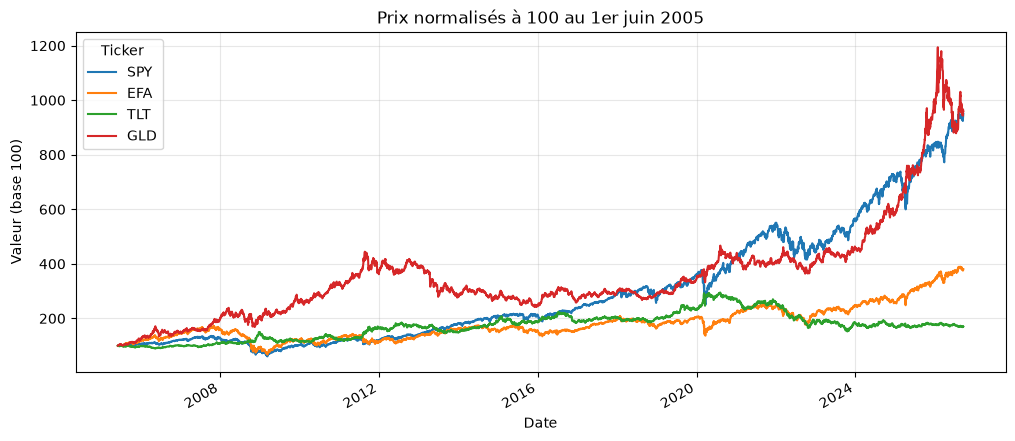

In [20]:
normalized = prices / prices.iloc[0] * 100

normalized.plot(figsize=(12, 5))
plt.title("Prix normalisés à 100 au 1er juin 2005")
plt.ylabel("Valeur (base 100)")
plt.grid(alpha=0.3)
plt.show()

<Axes: xlabel='Date'>

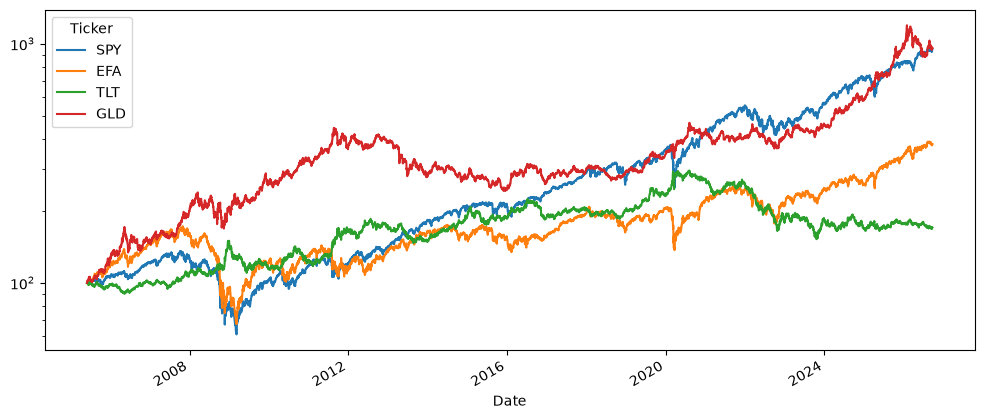

In [21]:
normalized.plot(figsize=(12, 5), logy=True)